# 1. Importing the Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


# 2. Reading the Dataset

In [2]:
df = pd.read_csv('../model/flood_dataset.csv')
print(df.head())

   Temp  Humidity  Cloud Cover  ANNUAL  Jan-Feb  Mar-May  Jun-Sep  Oct-Dec  \
0    29        70           30  3248.6     73.4    386.2   2122.8    666.1   
1    28        75           40  3326.6      9.3    275.7   2403.4    638.2   
2    28        75           42  3271.2     21.7    336.3   2343.0    570.1   
3    29        71           44  3129.7     26.7    339.4   2398.2    365.3   
4    31        74           40  2741.6     23.4    378.5   1881.5    458.1   

      avgjune    sub  flood  
0  274.866667  649.9      0  
1  130.300000  256.4      1  
2  186.200000  308.9      0  
3  366.066667  862.5      0  
4  283.400000  586.9      0  


# 3. Univariate Analysis

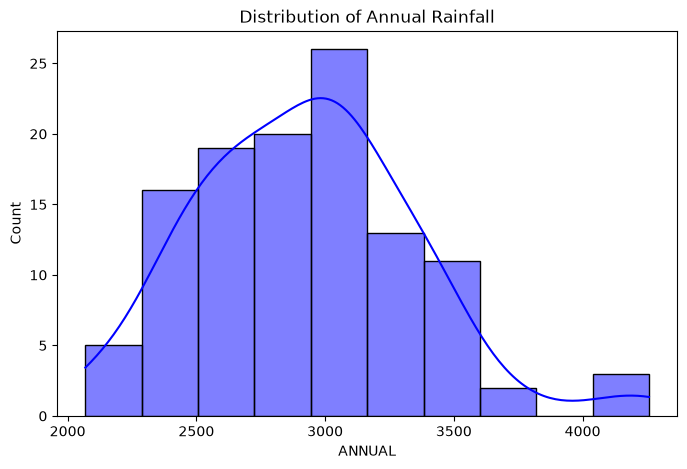

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(df['ANNUAL'], kde=True, color='blue')
plt.title('Distribution of Annual Rainfall')
plt.show()

# 4. Multivariate Analysis

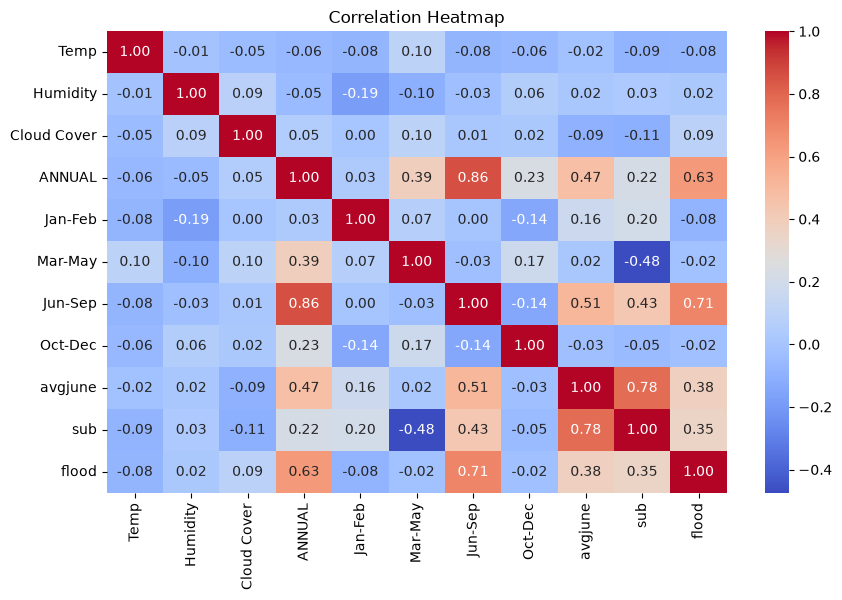

In [4]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# 5. Descriptive Analysis

In [5]:
print(df.describe().T)

             count         mean         std     min          25%          50%  \
Temp         115.0    29.600000    1.122341    28.0    29.000000    30.000000   
Humidity     115.0    73.852174    2.947623    70.0    71.000000    74.000000   
Cloud Cover  115.0    36.286957    4.330158    30.0    32.500000    36.000000   
ANNUAL       115.0  2925.487826  422.112193  2068.8  2627.900000  2937.500000   
Jan-Feb      115.0    27.739130   22.361032     0.3    10.250000    20.500000   
Mar-May      115.0   377.253913  151.091850    89.9   276.750000   342.000000   
Jun-Sep      115.0  2022.840870  386.254397  1104.3  1768.850000  1948.700000   
Oct-Dec      115.0   497.636522  129.860643   166.6   407.450000   501.500000   
avgjune      115.0   218.100870   62.547597    65.6   179.666667   211.033333   
sub          115.0   439.801739  210.438813    34.2   295.000000   430.600000   
flood        115.0     0.139130    0.347597     0.0     0.000000     0.000000   

                     75%   

# 6. Handling Missing Values
The dataset is clean and has no missing values.

In [6]:
print(df.isnull().sum())

Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64


# 7. Handling Outliers
Using IQR to detect and handle outliers in the dataset.

In [7]:
def handle_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[column] = np.where(data[column] > upper_bound, upper_bound,
                   np.where(data[column] < lower_bound, lower_bound, data[column]))
    return data

for col in df.columns[:-1]: # exclude target
    df = handle_outliers(df, col)

# 8. Handling Categorical Values
Our dataset contains only numerical features, so no categorical encoding is necessary.

In [8]:
print(df.dtypes)

Temp           float64
Humidity       float64
Cloud Cover    float64
ANNUAL         float64
Jan-Feb        float64
Mar-May        float64
Jun-Sep        float64
Oct-Dec        float64
avgjune        float64
sub            float64
flood            int64
dtype: object


# 9. Splitting Data into Training and Test Sets

In [9]:
X = df.drop('flood', axis=1)
y = df['flood']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")

Training Data: (92, 10), Testing Data: (23, 10)


# 10. Feature Scaling

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 11. Decision Tree Model

In [11]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_preds = dt_model.predict(X_test_scaled)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_preds) * 100:.2f}%")

Decision Tree Accuracy: 95.65%


# 12. Random Forest Model

In [12]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds) * 100:.2f}%")

Random Forest Accuracy: 95.65%


# 13. KNN Model

In [13]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)
knn_preds = knn_model.predict(X_test_scaled)
print(f"KNN Accuracy: {accuracy_score(y_test, knn_preds) * 100:.2f}%")

KNN Accuracy: 86.96%


# 14. XGBoost Model

In [14]:
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds) * 100:.2f}%")

XGBoost Accuracy: 86.96%


# 15. Comparing the Models

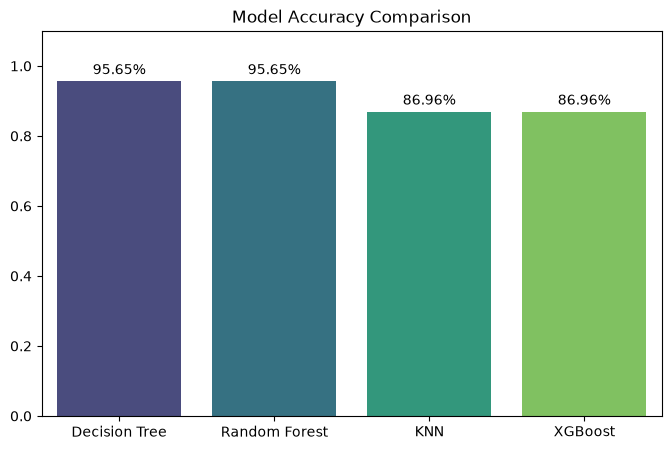

In [15]:
models = ['Decision Tree', 'Random Forest', 'KNN', 'XGBoost']
accuracies = [
    accuracy_score(y_test, dt_preds),
    accuracy_score(y_test, rf_preds),
    accuracy_score(y_test, knn_preds),
    accuracy_score(y_test, xgb_preds)
]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1.1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v*100:.2f}%", ha='center')
plt.show()

# 16. Evaluating Performance and Saving the Model
Saving the best model (Random Forest / XGBoost) and the StandardScaler for deployment.

In [16]:
print(classification_report(y_test, rf_preds, zero_division=0))
joblib.dump(rf_model, '../model/floods.save')
joblib.dump(scaler, '../model/scaler.save')
print('Model and Scaler Saved Successfully!')

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23

Model and Scaler Saved Successfully!


# 17. Building HTML Pages
The HTML pages for the user interface are built using Jinja2 templates (located in the `templates/` folder of the Flask app). They include:
- `home.html`: Dashboard
- `predict.html`: Input form for our 10 features
- `result_flood.html` & `result_noflood.html`: Dynamic result pages.

# 18. Build the Python Script (app.py)
The `app.py` script utilizes Flask to handle routing, receive input from the HTML forms, scale the data using `scaler.save`, and make predictions using `floods.save`.

# 19. Run the Application
To run the application locally, execute `python app.py` in the terminal and navigate to `http://127.0.0.1:5000/`.